In [1]:
from google.colab import files
import zipfile
import os
import pandas as pd

# Step 1 - Upload
uploaded = files.upload()  # select churn.csv.zip

# Step 2 - Unzip (correct filename)
with zipfile.ZipFile('churn.csv.zip', 'r') as z:
    z.extractall('/content/')

# Step 3 - Check what files came out
print(os.listdir('/content/'))

# Step 4 - Load
df = pd.read_csv('/content/telco.csv')
print("✅ Loaded!", df.shape)
print(df.head())

Saving churn.csv.zip to churn.csv.zip
['.config', 'churn.csv.zip', 'telco.csv', 'sample_data']
✅ Loaded! (7043, 50)
  Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   
2  1658-BYGOY    Male   71       No            Yes      No        Yes   
3  4598-XLKNJ  Female   78       No            Yes     Yes        Yes   
4  4846-WHAFZ  Female   80       No            Yes     Yes        Yes   

   Number of Dependents        Country       State  ...  \
0                     0  United States  California  ...   
1                     1  United States  California  ...   
2                     3  United States  California  ...   
3                     1  United States  California  ...   
4                     1  United States  California  ...   

  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
0               

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
df = pd.read_csv('/content/telco.csv')
print("✅ Data loaded!")
print("Shape:", df.shape)

✅ Data loaded!
Shape: (7043, 50)


In [4]:
print("\nChurn column name check:")
print([col for col in df.columns if 'Churn' in col])
print("\nChurn Label unique values:")
print(df['Churn Label'].unique())


Churn column name check:
['Churn Label', 'Churn Score', 'Churn Category', 'Churn Reason']

Churn Label unique values:
['Yes' 'No']


In [5]:
# Select important columns
cols = ['Gender', 'Age', 'Senior Citizen', 'Married', 'Tenure in Months',
        'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
        'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
        'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
        'Payment Method', 'Monthly Charge', 'Total Charges', 'Churn Label']

df = df[cols].copy()
df.rename(columns={'Churn Label': 'Churn'}, inplace=True)

# Clean
df.dropna(inplace=True)
df = df[df['Churn'].isin(['Yes', 'No'])]
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].astype(int)

print("✅ Data cleaned!")
print("Shape:", df.shape)
print("Churn distribution:")
print(df['Churn'].value_counts())

✅ Data cleaned!
Shape: (7043, 20)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64



Cell 3 — "Encode Text Columns"

In [6]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns
print("Text columns:", list(cat_cols))

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("✅ Encoding done!")
print("Shape:", df.shape)
df.head()

Text columns: ['Gender', 'Senior Citizen', 'Married', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
✅ Encoding done!
Shape: (7043, 20)


,Gender,Age,Senior Citizen,Married,Tenure in Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Churn
0,1,78,1,0,1,0,0,1,0,0,1,0,0,1,0,1,0,39.65,39.65,1
1,0,74,1,1,8,1,1,1,0,1,0,0,0,0,0,1,1,80.65,633.30,1
2,1,71,1,0,18,1,1,1,0,0,0,0,1,1,0,1,0,95.45,1752.55,1
3,0,78,1,1,25,1,0,1,0,1,1,0,1,1,0,1,0,98.50,2514.50,1
4,0,80,1,1,37,1,1,1,0,0,0,0,0,0,0,1,0,76.50,2868.15,1


**Cell 4 — EDA Plot 1: Churn Distribution**


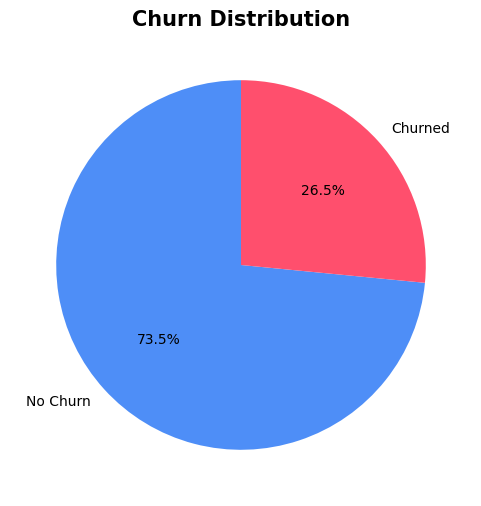

In [7]:
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No Churn', 'Churned'],
    colors=['#4e8ef7', '#ff4f6d'],
    startangle=90
)
plt.title('Churn Distribution', fontsize=15, fontweight='bold')
plt.ylabel('')
plt.show()

**Cell 5 — EDA Plot 2: Contract vs Churn**


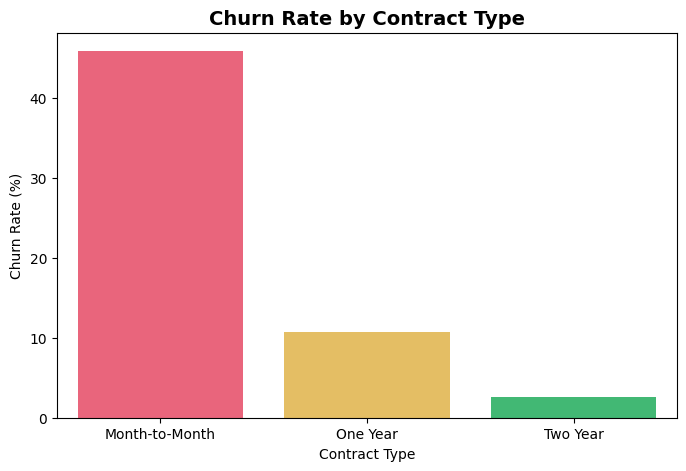

In [8]:
df_raw = pd.read_csv('/content/telco.csv')
df_raw.rename(columns={'Churn Label': 'Churn'}, inplace=True)

plt.figure(figsize=(8,5))
contract_churn = df_raw.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()

sns.barplot(x='Contract', y='Churn', data=contract_churn,
            palette=['#ff4f6d', '#f9c74f', '#2ecc71'])
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.show()

Cell 6 — EDA Plot 3: Monthly Charge vs Churn

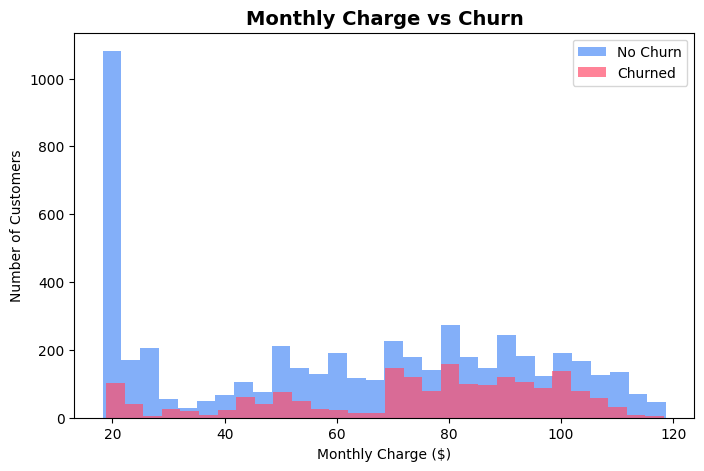

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df_raw[df_raw['Churn']=='No']['Monthly Charge'],
         bins=30, alpha=0.7, color='#4e8ef7', label='No Churn')
plt.hist(df_raw[df_raw['Churn']=='Yes']['Monthly Charge'],
         bins=30, alpha=0.7, color='#ff4f6d', label='Churned')
plt.title('Monthly Charge vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charge ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

Cell 7 — EDA Plot 4: Tenure vs Churn

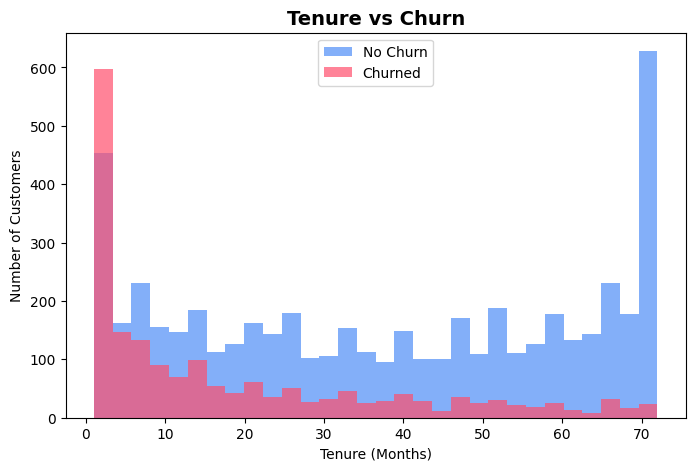

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df_raw[df_raw['Churn']=='No']['Tenure in Months'],
         bins=30, alpha=0.7, color='#4e8ef7', label='No Churn')
plt.hist(df_raw[df_raw['Churn']=='Yes']['Tenure in Months'],
         bins=30, alpha=0.7, color='#ff4f6d', label='Churned')
plt.title('Tenure vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

Cell 8 — Split Data

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Split done!")
print("Training size:", X_train.shape)
print("Testing size :", X_test.shape)

X shape: (7043, 19)
y shape: (7043,)
✅ Split done!
Training size: (5634, 19)
Testing size : (1409, 19)


Cell 9 — Scale Data

In [12]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling done!")

✅ Scaling done!


Cell 10 — Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

lr_acc = accuracy_score(y_test, lr_pred)
lr_roc = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])

print("✅ Logistic Regression Results:")
print(f"   Accuracy : {lr_acc*100:.1f}%")
print(f"   ROC-AUC  : {lr_roc:.3f}")
print("\nFull Report:")
print(classification_report(y_test, lr_pred,
      target_names=['No Churn', 'Churned']))

✅ Logistic Regression Results:
   Accuracy : 81.1%
   ROC-AUC  : 0.870

Full Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1009
     Churned       0.69      0.61      0.65       400

    accuracy                           0.81      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.81      0.81      1409



Cell 11 — Decision Tree

In [14]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_roc = roc_auc_score(y_test, dt.predict_proba(X_test)[:,1])

print("✅ Decision Tree Results:")
print(f"   Accuracy : {dt_acc*100:.1f}%")
print(f"   ROC-AUC  : {dt_roc:.3f}")
print("\nFull Report:")
print(classification_report(y_test, dt_pred,
      target_names=['No Churn', 'Churned']))

✅ Decision Tree Results:
   Accuracy : 80.6%
   ROC-AUC  : 0.854

Full Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1009
     Churned       0.70      0.54      0.61       400

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Cell 12 — Confusion Matrix

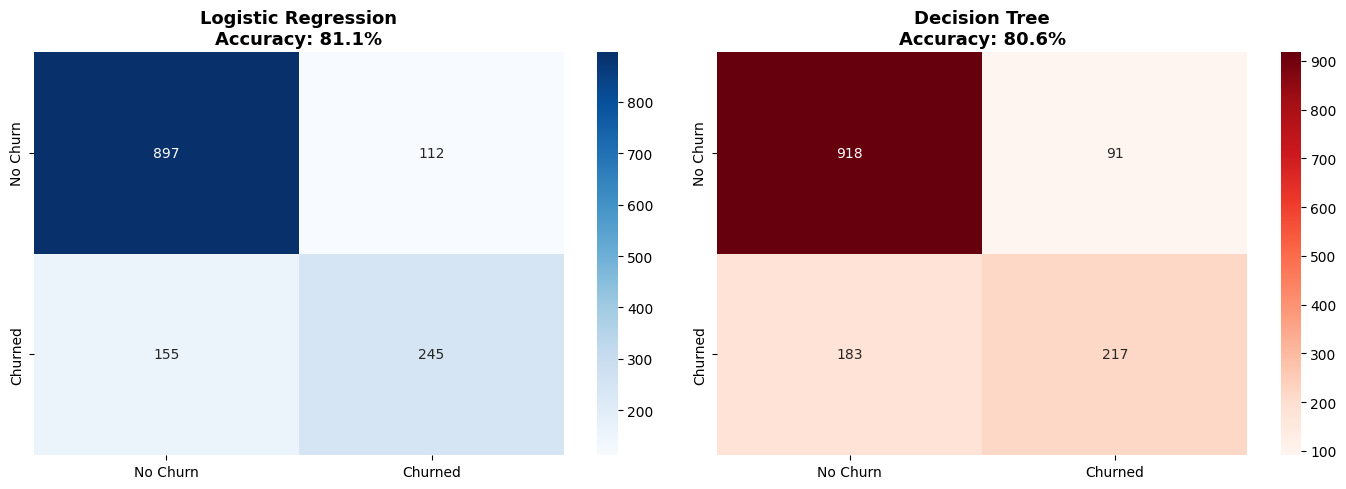

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churned'],
            yticklabels=['No Churn','Churned'])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.1f}%',
                  fontsize=13, fontweight='bold')

cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No Churn','Churned'],
            yticklabels=['No Churn','Churned'])
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_acc*100:.1f}%',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Cell 13 — Feature Importance

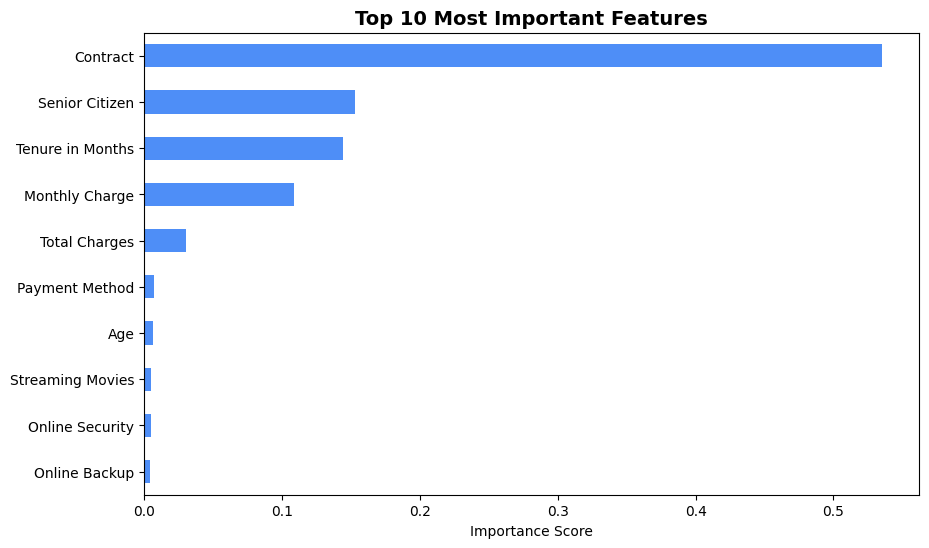

In [17]:
plt.figure(figsize=(10,6))

feat_imp = pd.Series(dt.feature_importances_,
                     index=X.columns).nlargest(10)
feat_imp.sort_values().plot(kind='barh', color='#4e8ef7')

plt.title('Top 10 Most Important Features',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.show()

Cell 14 — Final Summary

In [18]:
print("=" * 45)
print("       FINAL MODEL COMPARISON")
print("=" * 45)
print(f"  Logistic Regression → Accuracy: {lr_acc*100:.1f}%  ROC: {lr_roc:.3f}")
print(f"  Decision Tree       → Accuracy: {dt_acc*100:.1f}%  ROC: {dt_roc:.3f}")
print("=" * 45)

if lr_roc > dt_roc:
    print("🏆 Best Model: Logistic Regression")
else:
    print("🏆 Best Model: Decision Tree")

print("\n📌 Key Business Findings:")
print("  ✅ Month-to-month contracts churn the most")
print("  ✅ New customers leave more than old ones")
print("  ✅ Higher monthly charges = more churn risk")
print("  ✅ Customers without tech support churn more")

       FINAL MODEL COMPARISON
  Logistic Regression → Accuracy: 81.1%  ROC: 0.870
  Decision Tree       → Accuracy: 80.6%  ROC: 0.854
🏆 Best Model: Logistic Regression

📌 Key Business Findings:
  ✅ Month-to-month contracts churn the most
  ✅ New customers leave more than old ones
  ✅ Higher monthly charges = more churn risk
  ✅ Customers without tech support churn more
